In [ ]:
#--INSTALLING NECESSARY AIF360 FEATURES FOR REWEIGHING --#

In [1]:
!pip install aif360

In [ ]:
!pip install aif360[AdversarialDebiasing]

In [ ]:
!pip install aif360[Reductions]
!pip install aif360[inFairness]

In [ ]:
#--PRE-PROCESSING DATASET BEFORE REWEGHING ("SelectedClean_nhis2023.csv")

In [35]:
#Loading Cleaned Data and turning attributes into numeric (encoding)

import pandas as pd
import numpy as np

df = pd.read_csv("SelectedClean_nhis2023.csv")

df['ANXEV_A'] = df['ANXEV_A'].map({'Yes': 1, 'No': 0}).astype(int)
df['SEX_A'] = df['SEX_A'].map({'Male': 0, 'Female': 1}).astype(int)
df['HISPALLP_BIN'] = df['HISPALLP_A'].map({
    'Non-Hispanic White only': 1,  
    'Hispanic': 0,
    'Non-Hispanic Black/African American only': 0,
    'Non-Hispanic Asian only': 0,
    'Non-Hispanic AIAN only': 0,
    'Non-Hispanic AIAN and any other group': 0,
    'Multiple races': 0
}).astype(int)

df_aif = df.copy().reset_index().rename(columns={"index": "row_id"})

print(df_aif.head())

   row_id                                HISPALLP_A  SEX_A  AGEP_A  ANXEV_A  \
0       0  Non-Hispanic Black/African American only      0      67        0   
1       1                   Non-Hispanic White only      0      73        0   
2       2  Non-Hispanic Black/African American only      0      48        0   
3       3                   Non-Hispanic White only      1      42        0   
4       4                   Non-Hispanic White only      1      50        0   

   HISPALLP_BIN  
0             0  
1             1  
2             0  
3             1  
4             1  


In [45]:
# Measuring Fairness metrics before reweighing

from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric

def dataset_fairness_metrics(df, label_attr, protected_attr):
        
    # Create BinaryLabelDataset for AIF360
    dataset = BinaryLabelDataset(
        favorable_label=1, # ANXEV_A >> Yes 
        unfavorable_label=0, # ANXEV_A >> No
        df=df[[label_attr, protected_attr]],
        label_names=[label_attr],
        protected_attribute_names=[protected_attr]
    )
    
    metric = BinaryLabelDatasetMetric(
        dataset,
        unprivileged_groups=[{protected_attr: 0}], # SEX_A >> male and HISPALLP_BIN >> Non-Hispanic White-only
        privileged_groups=[{protected_attr: 1}]    # SEX_A >> female and HISPALLP_BIN >> Hispanic + other minorities
    )

    # Compute values
    di = metric.disparate_impact()
    spd = metric.statistical_parity_difference()
    
    print(f"\nFairness Metrics for {protected_attr}:") # group fairness metrics based on privileged vs. unprivileged
    print(f"Disparate Impact: {di:.4f}") # restrict results at 4 decimal places
    print(f"Statistical Parity Difference: {spd:.4f}") # restrict results at 4 decimal places
    

print("=== Before Reweighing (SEX_A) ===")
dataset_fairness_metrics(df_aif, label_attr='ANXEV_A', protected_attr='SEX_A')

print("\n=== Before Reweighing (HISPALLP_BIN) ===")
dataset_fairness_metrics(df_aif, label_attr='ANXEV_A', protected_attr='HISPALLP_BIN')




=== Before Reweighing (SEX_A) ===

Fairness Metrics for SEX_A:
Disparate Impact: 0.5613
Statistical Parity Difference: -0.1010

=== Before Reweighing (HISPALLP_BIN) ===

Fairness Metrics for HISPALLP_BIN:
Disparate Impact: 0.6413
Statistical Parity Difference: -0.0752


In [ ]:
#-- SINGULAR REWEGHING OF PROTECTED ATTRIBUTES--

In [42]:
#Reweighing protected attributes

from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing

def reweighing(df, label_attr, protected_attr, fav_label=1, unfav_label=0):
    dataset_orig = BinaryLabelDataset(
        favorable_label=fav_label, # ANXEV_A >> Yes 
        unfavorable_label=unfav_label, # ANXEV_A >> No
        df=df[["row_id", label_attr, protected_attr]],
        label_names=[label_attr],
        protected_attribute_names=[protected_attr]
    )
    
    # Identify privileged and unprivileged groups
    categories = df[protected_attr].unique().tolist()
    RW = Reweighing(unprivileged_groups=[{protected_attr: categories[0]}], # SEX_A >> male and HISPALLP_BIN >> Non-Hispanic White-only
                    privileged_groups=[{protected_attr: categories[1]}]) # SEX_A >> female and HISPALLP_BIN >> Hispanic + other minorities

    # Fit and transform
    dataset_transf = RW.fit_transform(dataset_orig)

    # Convert to DataFrame and include instance weights
    df_balanced, _ = dataset_transf.convert_to_dataframe()
    df_balanced["instance_weight"] = dataset_transf.instance_weights
    
    print(f"Finished reweighing for {protected_attr}")
    return dataset_transf, df_balanced


    # Run reweighing 
ds_sex_balanced, df_sex_balanced = reweighing(df_aif, "ANXEV_A", "SEX_A")
ds_hisp_balanced, df_hisp_balanced = reweighing(df_aif, "ANXEV_A", "HISPALLP_BIN")

# Merge weights back into full dataset
df_sex_full = df_aif.merge(df_sex_balanced[["row_id", "instance_weight"]], on="row_id", how="left")
df_hisp_full = df_aif.merge(df_hisp_balanced[["row_id", "instance_weight"]], on="row_id", how="left")



Finished reweighing for SEX_A
Finished reweighing for HISPALLP_BIN


In [7]:
print(df_sex_balanced.head())
print(df_hisp_balanced.head())


   row_id  SEX_A  ANXEV_A  instance_weight
0     0.0    0.0      0.0         0.936879
1     1.0    0.0      0.0         0.936879
2     2.0    0.0      0.0         0.936879
3     3.0    1.0      0.0         1.059797
4     4.0    1.0      0.0         1.059797
   row_id  HISPALLP_BIN  ANXEV_A  instance_weight
0     0.0           0.0      0.0         0.942604
1     1.0           1.0      0.0         1.032336
2     2.0           0.0      0.0         0.942604
3     3.0           1.0      0.0         1.032336
4     4.0           1.0      0.0         1.032336


In [46]:
#Measuring Fairness metrics after reweghing
from aif360.metrics import BinaryLabelDatasetMetric

def dataset_fairness_metrics_aif(dataset, protected_attr):
    metric = BinaryLabelDatasetMetric(
        dataset,
        unprivileged_groups=[{protected_attr: 0}], # SEX_A >> male and HISPALLP_BIN >> Non-Hispanic White-only
        privileged_groups=[{protected_attr: 1}] # SEX_A >> female and HISPALLP_BIN >> Hispanic + other minorities
    )
    
    # Compute values
    di = metric.disparate_impact()
    spd = metric.statistical_parity_difference()
    
    print(f"\nFairness Metrics for {protected_attr}:") # group fairness metrics based on privileged vs. unprivileged
    print(f"Disparate Impact: {di:.4f}") # restrict results at 4 decimal places
    print(f"Statistical Parity Difference: {spd:.4f}") # restrict results at 4 decimal places


print("\nAfter Reweighing:")
dataset_fairness_metrics_aif(ds_sex_balanced, "SEX_A")

print("\nAfter Reweighing:")
dataset_fairness_metrics_aif(ds_hisp_balanced, "HISPALLP_BIN")




After Reweighing:

Fairness Metrics for SEX_A:
Disparate Impact: 1.0000
Statistical Parity Difference: 0.0000

After Reweighing:

Fairness Metrics for HISPALLP_BIN:
Disparate Impact: 1.0000
Statistical Parity Difference: 0.0000


In [47]:
# Comparison metrics before and after reweighing

import pandas as pd
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric

def collect_fairness_comparison(df_before, ds_after, label_attr, protected_attr, fav_label=1, unfav_label=0):
    
    #df_before : pandas.DataFrame with original data
    #ds_after  : aif360.datasets.BinaryLabelDataset (after reweighing)
    
    
    # Build AIF dataset for BEFORE
    dataset_before = BinaryLabelDataset(
        favorable_label=fav_label,
        unfavorable_label=unfav_label,
        df=df_before[[label_attr, protected_attr]],
        label_names=[label_attr],
        protected_attribute_names=[protected_attr]
    )

  
    # Metrics BEFORE
    metric_before = BinaryLabelDatasetMetric(
        dataset_before,
        unprivileged_groups=[{protected_attr: 0}], # SEX_A >> male and HISPALLP_BIN >> Non-Hispanic White-only
        privileged_groups=[{protected_attr: 1}] # SEX_A >> female and HISPALLP_BIN >> Hispanic + other minorities
    )

    # Metrics AFTER
    metric_after = BinaryLabelDatasetMetric(
        ds_after,
        unprivileged_groups=[{protected_attr: 0}], # SEX_A >> male and HISPALLP_BIN >> Non-Hispanic White-only
        privileged_groups=[{protected_attr: 1}] # SEX_A >> female and HISPALLP_BIN >> Hispanic + other minorities
    )

    # Collect results
    results = pd.DataFrame({
        "Metric": ["Disparate Impact", "Statistical Parity Difference"],
        "Before": [metric_before.disparate_impact(),
                   metric_before.statistical_parity_difference()],
        "After": [metric_after.disparate_impact(),
                  metric_after.statistical_parity_difference()]
    })

    results = results.round(4)  # restrict results at 4 decimal places
    
    return results

results_sex = collect_fairness_comparison(df_aif, ds_sex_balanced, "ANXEV_A", "SEX_A")
results_hisp = collect_fairness_comparison(df_aif, ds_hisp_balanced, "ANXEV_A", "HISPALLP_BIN")

print("\n=== Fairness Comparison for SEX_A ===")
print(results_sex)

print("\n=== Fairness Comparison for HISPALLP_BIN ===")
print(results_hisp)




=== Fairness Comparison for SEX_A ===
                          Metric  Before  After
0               Disparate Impact  0.5613    1.0
1  Statistical Parity Difference -0.1010    0.0

=== Fairness Comparison for HISPALLP_BIN ===
                          Metric  Before  After
0               Disparate Impact  0.6413    1.0
1  Statistical Parity Difference -0.0752    0.0


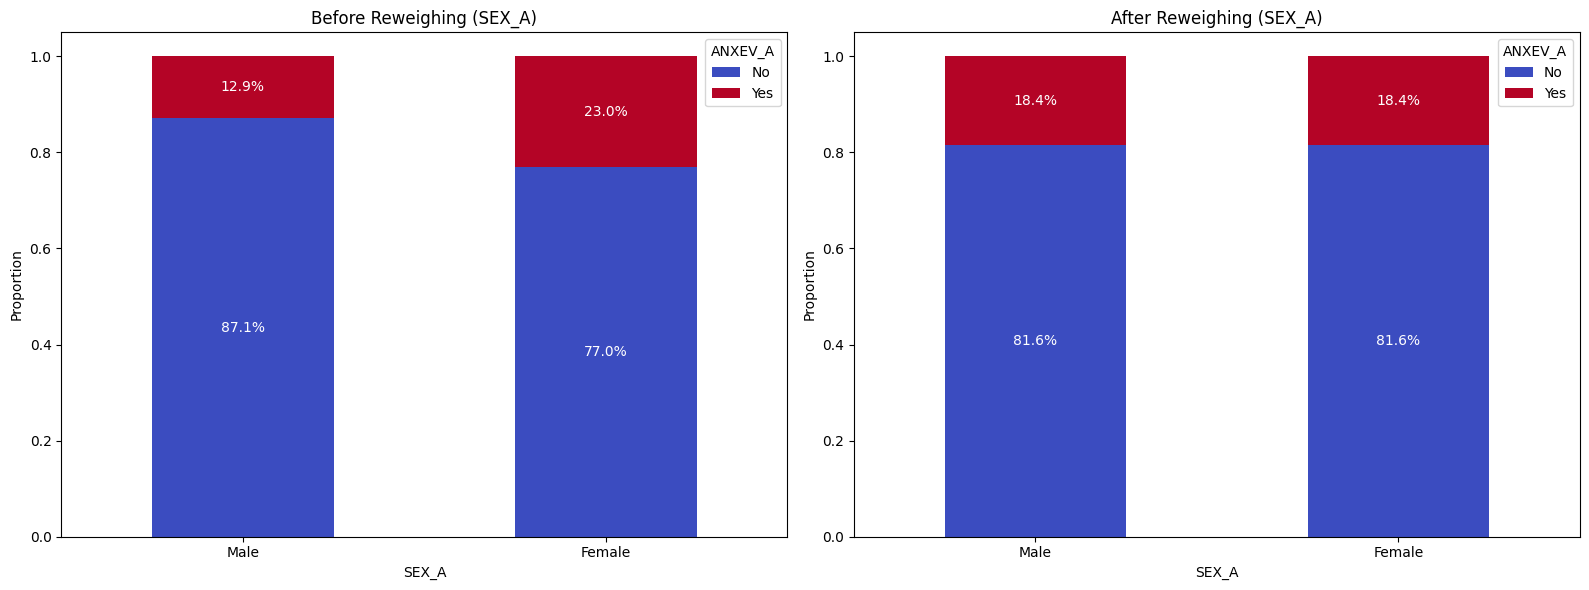

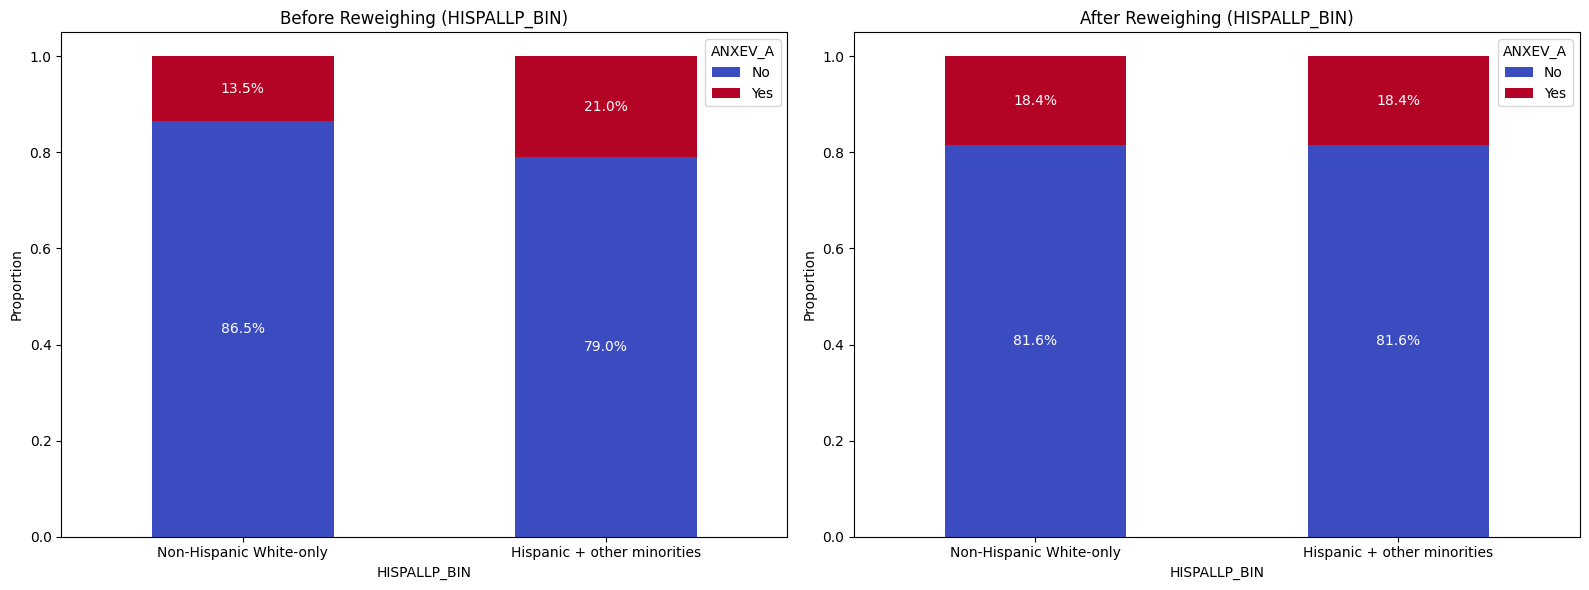

In [20]:
#Compare before vs. after reweighing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def compare_before_after(original_df, balanced_ds, target, protected):

    #mapping readable lables for target and prottected attributes
    target_labels = {0: "No", 1: "Yes"}
    protected_labels_map = {
        "SEX_A": {0: "Male", 1: "Female"},
        "HISPALLP_BIN": {0: "Non-Hispanic White-only", 1: "Hispanic + other minorities"}
    }
    x_labels_map = protected_labels_map.get(protected, None)
    

    #BEFORE: Normalize by row to get percentages
    before = pd.crosstab(original_df[protected], original_df[target], normalize="index")
    before.rename(columns=target_labels, inplace=True)
    before.index = before.index.astype(int)
    
    # AFTER: weighted percentages
    df_balanced, _ = balanced_ds.convert_to_dataframe()
    weights = balanced_ds.instance_weights
    
    after = (
        df_balanced
        .assign(weights=weights)
        .groupby([protected, target])['weights']
        .sum()
        .groupby(level=0)
        .apply(lambda x: x / x.sum())
        .unstack(fill_value=0)
    )
    after.rename(columns=target_labels, inplace=True)

    # Fix index for MultiIndex after-Reweighing
    if isinstance(after.index, pd.MultiIndex):
        after = after.reset_index(level=1, drop=True)

    after.index = after.index.astype(int)
    
    
    #Plot Graph
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    cmap = plt.get_cmap("coolwarm")

    for i, (df, title) in enumerate(zip([before, after], ["Before Reweighing", "After Reweighing"])):
        ax = axes[i]
        df.plot(kind="bar", stacked=True, ax=ax, colormap=cmap)
        ax.set_title(f"{title} ({protected})")
        ax.set_ylabel("Proportion")
        ax.set_xlabel(protected)
        if x_labels_map:
            ax.set_xticklabels([x_labels_map.get(x, str(x)) for x in df.index], rotation=0)
    
    # Add percentages inside bars
        for p in ax.patches:
            width, height = p.get_width(), p.get_height()
            if height > 0:  
                x, y = p.get_x(), p.get_y()
                ax.text(
                    x + width / 2, y + height / 2, f"{height*100:.1f}%", 
                    ha="center", va="center", color="white", fontsize=10
                )
        
    # Add legend for target labels
    axes[1].legend(title=target, labels=list(target_labels.values()))
    plt.tight_layout()
    plt.show()

# Comparing visualizations
compare_before_after(df_aif, ds_sex_balanced, "ANXEV_A", "SEX_A")
compare_before_after(df_aif, ds_hisp_balanced, "ANXEV_A", "HISPALLP_BIN")




In [18]:
# Save reweighed datasets
df_sex_full.to_csv("reweighed_full_SEX_A.csv", index=False)
df_hisp_full.to_csv("reweighed_full_HISPALLP.csv", index=False)

In [ ]:
#-- INTERSECTIONAL REWEGHING OF PROTECTED ATTRIBUTES--

In [55]:
# Reweighing with intersectional protected attributes and Including AGEP_A 

import pandas as pd
from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing

def reweigh_intersectional_with_age(
    df,
    label_attr,
    protected_attrs,
    age_col="AGEP_A",
    fav_label=1, # ANXEV_A >> Yes
    unfav_label=0, # ANXEV_A >> No
    add_scaled_age=True # AGEP_A_scaled in [0,1] for k-NN distances
):

    #Checking for any missing intersectional group
    print(f"\nChecking intersection of {protected_attrs} for empty groups...")
    cross_tab = pd.crosstab([df[attr] for attr in protected_attrs], df[label_attr])
    print(cross_tab)
    
    # Columns to include in the dataset that are "not label or protected"
    cols = ["row_id", label_attr] + protected_attrs + [age_col]
    
    # Construct BinaryLabelDataset for AIF360
    dataset_orig = BinaryLabelDataset(
        favorable_label=fav_label,
        unfavorable_label=unfav_label,
        df=df[cols],
        label_names=[label_attr],
        protected_attribute_names=protected_attrs
    )

    # Build privileged/unprivileged groups for all combinations
    unprivileged_groups = [{attr: 0 for attr in protected_attrs}] # SEX_A >> male and HISPALLP_BIN >> Non-Hispanic White-only
    privileged_groups   = [{attr: 1 for attr in protected_attrs}] # SEX_A >> female and HISPALLP_BIN >> Hispanic + other minorities

    #Call Reweighing algorith from AIF360
    RW = Reweighing(unprivileged_groups=unprivileged_groups,
                    privileged_groups=privileged_groups)
    dataset_transf = RW.fit_transform(dataset_orig)

    # Convert back to dataframe
    df_balanced, _ = dataset_transf.convert_to_dataframe()
    df_balanced["instance_weight"] = dataset_transf.instance_weights
    cols_to_fix = ["SEX_A", "HISPALLP_BIN", "ANXEV_A"]
    df_balanced[cols_to_fix] = df_balanced[cols_to_fix].astype(int)

    #Normalize AGEP_A between [0-1]
    if add_scaled_age:
        age_min = df_balanced[age_col].min()
        age_max = df_balanced[age_col].max()
        # Avoid division by zero if all ages are equal
        if pd.notnull(age_min) and pd.notnull(age_max) and age_max > age_min:
            df_balanced[f"{age_col}_scaled"] = (df_balanced[age_col] - age_min) / (age_max - age_min)
        else:
            # If all ages are identical, fall back to 0.0 everywhere to avoid division by zero.
            df_balanced[f"{age_col}_scaled"] = 0.0

    print(f"Finished intersectional reweighing for {protected_attrs} (age kept in '{age_col}')")
    return dataset_transf, df_balanced


# Run with SEX_A and HISPALLP_BIN; keep AGEP_A for graph work
ds_intersectional, df_intersectional = reweigh_intersectional_with_age(
    df_aif,
    label_attr="ANXEV_A",
    protected_attrs=["SEX_A", "HISPALLP_BIN"],
    age_col="AGEP_A",
    fav_label=1, # ANXEV_A >> Yes
    unfav_label=0, # ANXEV_A >> No
    add_scaled_age=True  # AGEP_A_scaled in [0,1] for k-NN distances
)

# Save csv file
df_intersectional.to_csv("reweighed_intersectional_with_age.csv", index=False)
print("Saved: reweighed_intersectional_with_age.csv")
print(df_intersectional.head())




Checking intersection of ['SEX_A', 'HISPALLP_BIN'] for empty groups...
ANXEV_A                0     1
SEX_A HISPALLP_BIN            
0     0             3971   418
      1             7721  1317
1     0             4690   928
      1             7652  2763
Finished intersectional reweighing for ['SEX_A', 'HISPALLP_BIN'] (age kept in 'AGEP_A')
Saved: reweighed_intersectional_with_age.csv
   row_id  SEX_A  HISPALLP_BIN  AGEP_A  ANXEV_A  instance_weight  \
0     0.0      0             0    67.0        0         0.901694   
1     1.0      0             1    73.0        0         1.000000   
2     2.0      0             0    48.0        0         0.901694   
3     3.0      1             1    42.0        0         1.110395   
4     4.0      1             1    50.0        0         1.110395   

   AGEP_A_scaled  
0       0.604938  
1       0.679012  
2       0.370370  
3       0.296296  
4       0.395062  


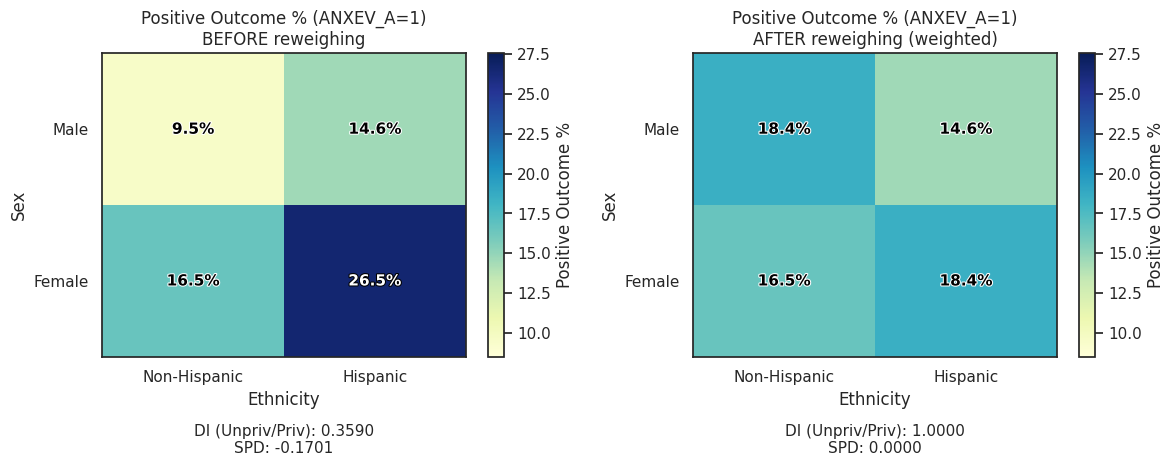

In [78]:
##Compare before vs. after intersectional reweighing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

#determine the best text color based on background
def get_text_color(rgba):
    r, g, b, _ = rgba
    brightness = 0.299*r + 0.587*g + 0.114*b # standard formula for dertemining "light" or "dark" color
    return 'white' if brightness < 0.5 else 'black'

# Build a positive-rate matrix
def _pos_rate_matrix_from_counts(ct: pd.DataFrame, index_names=('SEX_A','HISPALLP_BIN')):
     if not isinstance(ct.index, pd.MultiIndex): # Fix index for MultiIndex of integers
         ct.index = pd.MultiIndex.from_tuples(list(ct.index))
     ct.index = pd.MultiIndex.from_tuples([(int(a), int(b)) for a,b in ct.index],
                                          names=index_names)
    
    # positive rate per intersectional group (as %)
     pos_pct = (ct[1] / (ct[0] + ct[1]) * 100.0).unstack(level=index_names[1])

    # enforce row/col order 0,1 and add readable axis labels
     pos_pct = pos_pct.reindex(index=[0, 1], columns=[0, 1])
     pos_pct.index = pos_pct.index.map({0: "Male", 1: "Female"})
     pos_pct.columns = pos_pct.columns.map({0: "Non-Hispanic", 1: "Hispanic"})
     return pos_pct


#Compute fairness metrics
def _fairness_metrics_from_counts(ct: pd.DataFrame, unpriv=(0,0), priv=(1,1)):
    p_u = ct.loc[unpriv, 1] / (ct.loc[unpriv,0] + ct.loc[unpriv,1]) #unprivileged group as Male | Non-Hispanic
    p_p = ct.loc[priv,   1] / (ct.loc[priv,0]   + ct.loc[priv,1]) #privileged group as Female | Hispanic
    di  = float(p_u / p_p) if p_p > 0 else np.nan #Disparate Impact (DI)
    spd = float(p_u - p_p) #Statistical Parity Difference (SPD)
    return di, spd

# annotated heatmap  
def _annotated_heatmap(ax, M, title, cmap="YlGnBu", vmin=None, vmax=None):
    im = ax.imshow(M.values, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Ethnicity"); ax.set_ylabel("Sex")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Non-Hispanic","Hispanic"])
    ax.set_yticklabels(["Male","Female"])

    # add value text with adaptive color + thin outline for legibility
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            val = float(M.iloc[i, j])
            rgba = im.cmap(im.norm(val))
            txt_color = get_text_color(rgba)
            ax.text(
                j, i, f"{val:.1f}%", ha="center", va="center", color=txt_color, fontsize=11, fontweight="semibold",
                path_effects=[pe.withStroke(linewidth=1.5, foreground='black' if txt_color=='white' else 'white')]
            )
    return im

# Build before & after counts
cross_tab_before = pd.crosstab(
    [df_aif["SEX_A"], df_aif["HISPALLP_BIN"]],
    df_aif["ANXEV_A"]
)

cross_tab_after_w = pd.pivot_table(
   df_intersectional,
   index=["SEX_A","HISPALLP_BIN"], 
   columns="ANXEV_A",
   values="instance_weight", 
   aggfunc="sum", 
   fill_value=0
)

#Convert to percentage matrices
M_before = _pos_rate_matrix_from_counts(cross_tab_before)
M_after  = _pos_rate_matrix_from_counts(cross_tab_after_w)


#Compute fairness metrics
unpriv = (0,0); priv = (1,1)
di_b, spd_b = _fairness_metrics_from_counts(cross_tab_before, unpriv, priv)
di_a, spd_a = _fairness_metrics_from_counts(cross_tab_after_w, unpriv, priv)

# Plot Maps
vmin = min(M_before.min().min(), M_after.min().min())
vmax = max(M_before.max().max(), M_after.max().max())
vmin = max(0, vmin - 1); vmax = min(100, vmax + 1)

#Two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(12,5))

#same scale and colormap for both heatmaps
im0 = _annotated_heatmap(axes[0], M_before,
                         "Positive Outcome % (ANXEV_A=1)\nBEFORE reweighing",
                         cmap="YlGnBu", vmin=vmin, vmax=vmax)
im1 = _annotated_heatmap(axes[1], M_after,
                         "Positive Outcome % (ANXEV_A=1)\nAFTER reweighing (weighted)",
                         cmap="YlGnBu", vmin=vmin, vmax=vmax)

# colorbars for each heatmap
cbar0 = fig.colorbar(im0, ax=axes[0]); cbar0.set_label("Positive Outcome %")
cbar1 = fig.colorbar(im1, ax=axes[1]); cbar1.set_label("Positive Outcome %")

# metrics under each subplot
axes[0].text(0.5, -0.22, f"DI (Unpriv/Priv): {di_b:.4f}\nSPD: {spd_b:.4f}",
             ha="center", va="top", transform=axes[0].transAxes, fontsize=11)
axes[1].text(0.5, -0.22, f"DI (Unpriv/Priv): {di_a:.4f}\nSPD: {spd_a:.4f}",
             ha="center", va="top", transform=axes[1].transAxes, fontsize=11)

plt.tight_layout()
plt.show()


In [48]:
#code sources: 

#Reweighing pre-processing
   #https://aif360.readthedocs.io/en/stable/modules/generated/aif360.datasets.BinaryLabelDataset.html#aif360.datasets.BinaryLabelDataset
   #https://github.com/Trusted-AI/AIF360/blob/main/aif360/datasets/binary_label_dataset.py#L6-L48 
   #https://github.com/Trusted-AI/AIF360/blob/main/aif360/algorithms/preprocessing/reweighing.py#L18-L35
   #https://github.com/Trusted-AI/AIF360/blob/master/examples/tutorial_credit_scoring.ipynb
   #https://medium.com/@james.irving.phd/blog-post-series-ai-fairness-360-mitigating-bias-in-machine-learning-models-c1ec744c91c4
   #https://towardsdatascience.com/mitigating-bias-in-ai-with-aif360-b4305d1f88a9/

#Metrics
    #https://aif360.readthedocs.io/en/stable/modules/generated/aif360.datasets.BinaryLabelDataset.html#aif360.datasets.BinaryLabelDataset
    #https://github.com/Trusted-AI/AIF360/blob/main/aif360/datasets/binary_label_dataset.py#L6-L48
    #https://github.com/Trusted-AI/AIF360/blob/main/aif360/metrics/binary_label_dataset_metric.py#L108-L114
    #https://medium.com/@james.irving.phd/blog-post-series-ai-fairness-360-mitigating-bias-in-machine-learning-models-c1ec744c91c4
    #https://github.com/Trusted-AI/AIF360/blob/master/examples/metrics.ipynb
    #https://aif360.readthedocs.io/en/latest/modules/metrics.html

#Graphs
   #https://pandas.pydata.org/docs/reference/frame.html
   #https://pandas.pydata.org/docs/user_guide/visualization.html
   #1_Basics/31_Matplotlib_Pandas_Plotting.ipynb
   #2_Advanced/17_Matplotlib_Histograms.ipynb
   #2_Advanced/13_Matplotlib_Format_Charts.ipynb
   #2_Advanced/20_Seaborn_Intro.ipynb
   #https://www.w3schools.com/python/matplotlib_bars.asp
   #https://www.w3schools.com/python/matplotlib_labels.asp
   #https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.crosstab.html
   #https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.pivot_table.html
   #https://pandas.pydata.org/pandas-docs/stable/user_guide/advanced.html#multilevel-indexing
   #https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html
   #https://matplotlib.org/stable/tutorials/advanced/patheffects_guide.html
   #https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.colorbar.html
  
